# Time Series Local Change Interaction
**Author:** Alejandro Orellana

**Date:** Feburary 18, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal

**Purpose:** Used the time series local change model to explore which features of a building explains the buildings energy trends

## Section 1: Loading Data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf

from utils.data_utils import load_data
from utils.fix_effect_utils import (
    assign_top_level_property_type,
    map_community,
    ols_compare_and_pred_plot,
    plot_categorical_interactions_over_time,
    plotting_r_sqared,
    prepared_dataframe,
)

analysis_df = prepared_dataframe(load_data())
target_col = "Site EUI (kBtu/sq ft)"
analysis_df["geo_mapped_name"] = analysis_df["Community Area"].apply(map_community)
analysis_df = analysis_df.sort_values(["ID", "Data Year"])

2026-03-02 17:56:34,263 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-03-02 17:56:34,265 [INFO] Category counts:
COVID Impact Category
Other                  1296
Permanent              1816
Stable/Increased       7224
Temporary/Rebounded    1168


📊 Merging 33 rare types (<150) to 'other': ['mixed use property', 'k-12 school', 'other', 'hospital (general medical & surgical)', 'medical office', 'mall', 'residential care facility', 'laboratory', 'fitness center/health club/gym', 'strip mall', 'residence hall/dormitory', 'performing arts', 'library', 'other - entertainment/public assembly', 'other - mall', 'other - public services', 'enclosed mall', 'other - recreation', 'museum', 'other - specialty hospital', 'movie theater', 'wholesale club/supercenter', 'adult education', 'worship facility', 'financial office', 'social/meeting hall', 'prison/incarceration', 'recreation', 'other - services', 'pre-school/daycare', 'convention center', 'hospital', 'outpatient rehabilitation/physical therapy']


In [ ]:
analysis_df["log_eui"] = np.log(analysis_df[target_col])

analysis_df["next_year_log_eui"] = analysis_df.groupby("ID")["log_eui"].shift(-1)
analysis_df["building_future_change"] = (
    analysis_df["next_year_log_eui"] - analysis_df["log_eui"]
)

city_trend = analysis_df.groupby("Data Year")["building_future_change"].transform(
    "mean"
)

analysis_df["target_relative_growth"] = (
    analysis_df["building_future_change"] - city_trend
)

I made a new column called target_relative_growth (the dependent variable), which is the difference between the Site EUI change  (next year Site EUI - Current Site EUI) and the average Site EUI change for that data year.
I did this because I wanted to focus more on how a building's proportional change to the average change of all the rest of the city. To see whether a building is doing better or worse on average in the city.

The difference between the last ipynb is that site EUI is logged to better standardize spread

In [3]:
filling_cols = ["Gross Floor Area - Buildings (sq ft)", "Year Built"]
for col in filling_cols:
    analysis_df[col] = analysis_df.groupby("ID")[col].transform(
        lambda x: x.ffill().bfill()
    )

In [ ]:
remove_year = 2016
cut_off_year = 2022
analysis_df["previous_relative_growth"] = analysis_df.groupby("ID")[
    "target_relative_growth"
].shift(1)
analysis_df["Site_EUI_Lag1"] = analysis_df.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(
    1
)
analysis_df["Site_EUI_Lag2"] = analysis_df.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(
    2
)
analysis_df["Momentum"] = analysis_df["Site_EUI_Lag1"] - analysis_df["Site_EUI_Lag2"]

analysis_df = analysis_df[analysis_df["Data Year"] != remove_year]
train_df = analysis_df[analysis_df["Data Year"] < cut_off_year]
test_df = analysis_df[analysis_df["Data Year"] == cut_off_year]

# Plotting R-square

Running OLS on Target: target_relative_growth


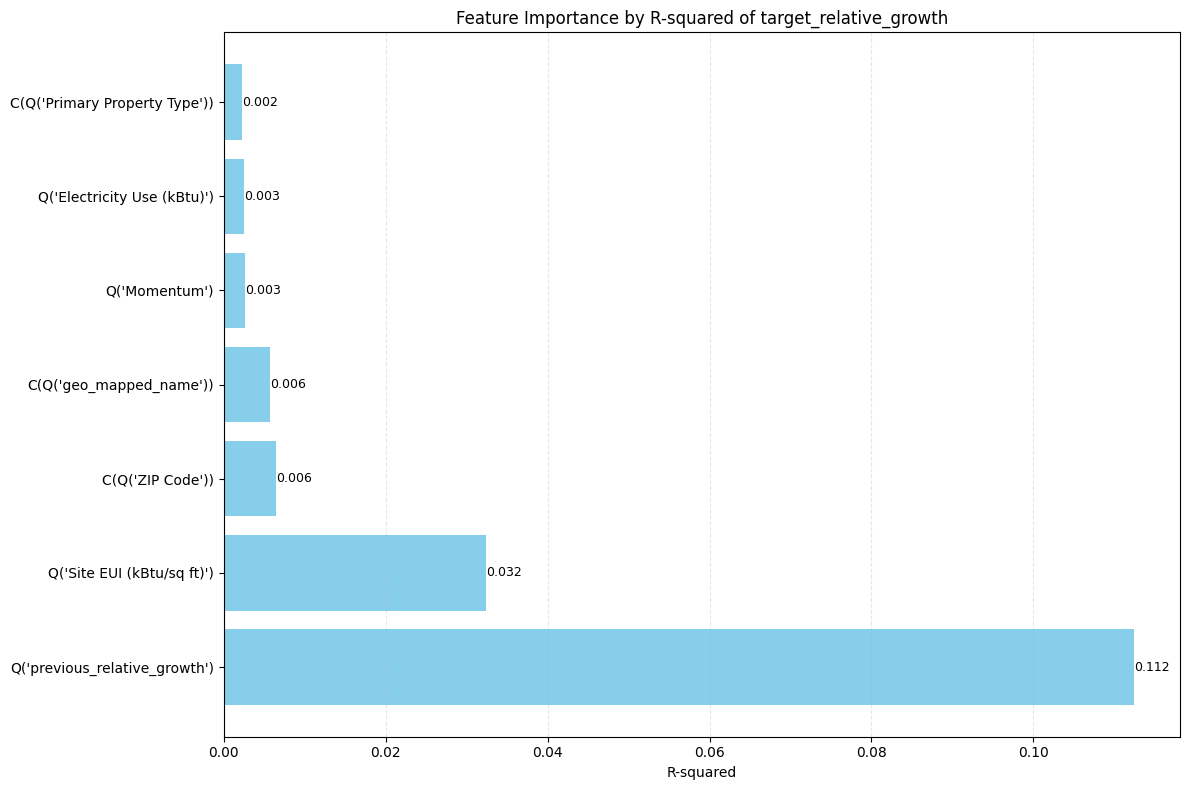

In [5]:
target_col = "target_relative_growth"
q_feature_cols = [
    "previous_relative_growth",
    "Momentum",
    "Electricity Use (kBtu)",
    "Site EUI (kBtu/sq ft)",
]
c_feature_cols = ["ZIP Code", "geo_mapped_name", "Primary Property Type"]
plotting_r_sqared(target_col, q_feature_cols, c_feature_cols, train_df)

The bar chart shows the R-squared values for selected columns, and, not surprisingly, the previous target_relative_growth (previous_relative_growth) column explains the most.
relative growth is logged

                                 OLS Regression Results                                
Dep. Variable:     Q('target_relative_growth')   R-squared:                       0.112
Model:                                     OLS   Adj. R-squared:                  0.112
Method:                          Least Squares   F-statistic:                     794.4
Date:                         Mon, 02 Mar 2026   Prob (F-statistic):          1.15e-164
Time:                                 17:56:35   Log-Likelihood:                 1996.5
No. Observations:                         6270   AIC:                            -3989.
Df Residuals:                             6268   BIC:                            -3976.
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------

/project/src/utils/fix_effect_utils.py:362: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


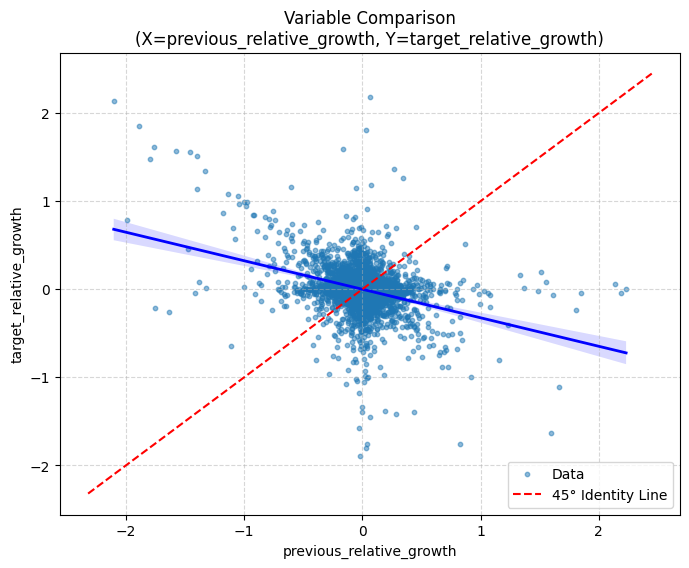

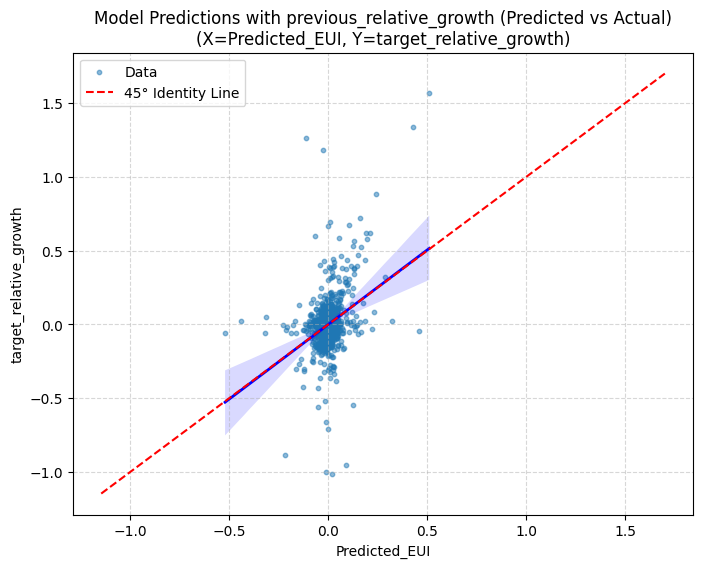

In [6]:
y_var = target_col
x_var = "previous_relative_growth"
formula = f"Q('{y_var}') ~ Q('{x_var}')"
ols_compare_and_pred_plot(formula, x_var, y_var, analysis_df, train_df, test_df)

The Variable comparison graph shows that there is mean reversion in the Site EUI change relative to the city (as the regression line slopes downward, with the red line for reference).
While the last graph used the model to predict the data (The data had a test/train split at 2022, so only 2022 and 2023 are being predicted), with the regression line being more in line with the 45-degree red line, it shows that so far, using previous_relative_growth.

The difference with the log version than to the previous time_series_local_change.ipynb is that it is much better at predicting the direction of the change as it is right on the 45 degree line

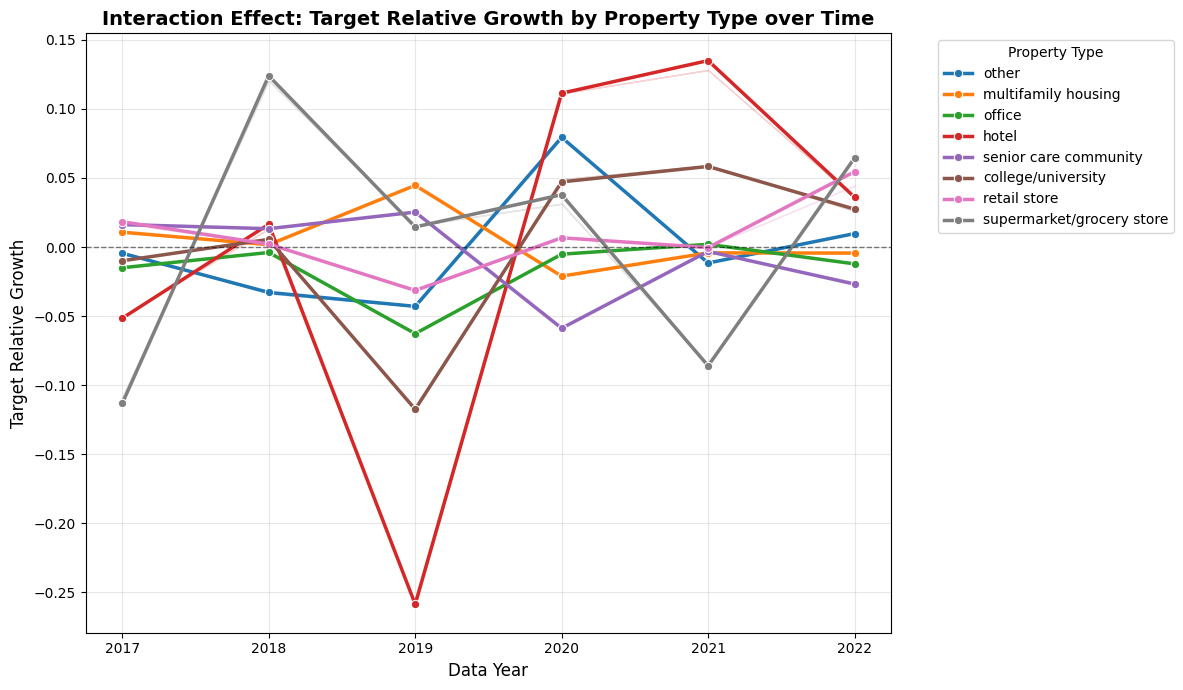

In [7]:
test_dataframe = assign_top_level_property_type(analysis_df)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=test_dataframe,
    x="Data Year",
    y="target_relative_growth",
    hue="Primary Property Type",
    marker="o",
    linewidth=2.5,
    errorbar=("ci", 0),
)

plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
plt.title(
    "Interaction Effect: Target Relative Growth by Property Type over Time",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Data Year", fontsize=12)
plt.ylabel("Target Relative Growth", fontsize=12)
plt.legend(title="Property Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

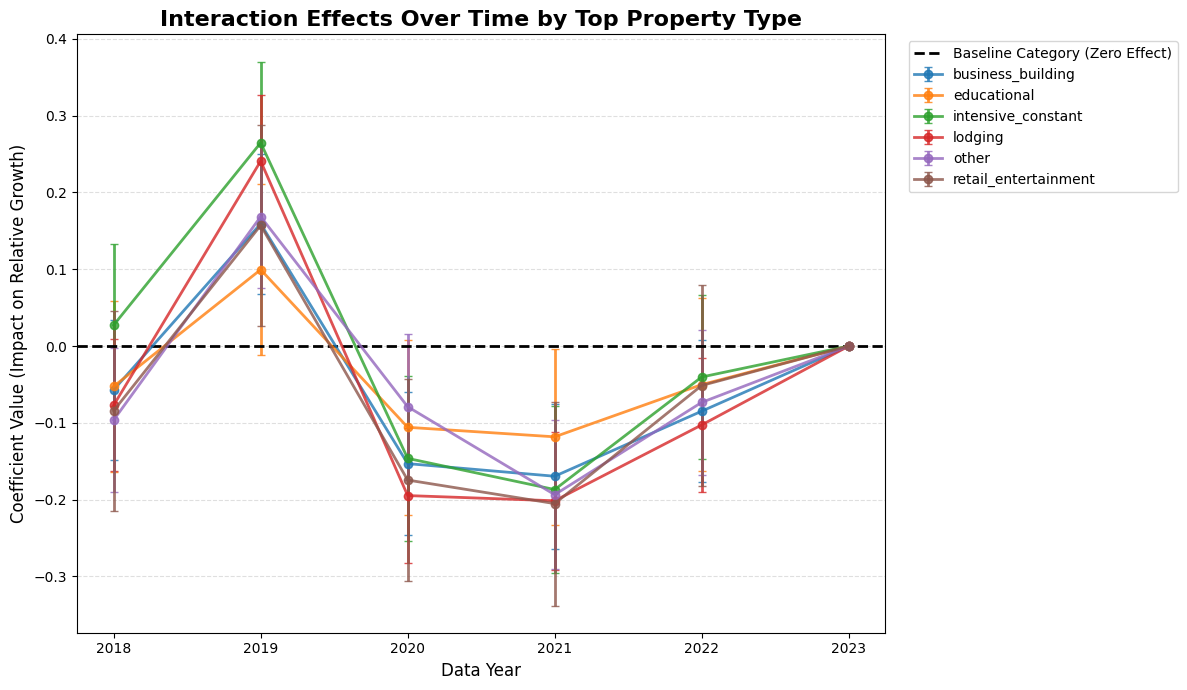

In [8]:
formula = (
    "Q('target_relative_growth') ~ C(Q('Data Year')) * C(Q('TopLevelPropertyType'))"
)
model = smf.ols(formula, data=test_dataframe).fit()

fig1, ax1 = plot_categorical_interactions_over_time(
    model=model,
    time_col="Data Year",
    category_col="TopLevelPropertyType",
    title="Interaction Effects Over Time by Top Property Type",
    xlabel="Data Year",
    ylabel="Coefficient Value (Impact on Relative Growth)",
)
plt.show()

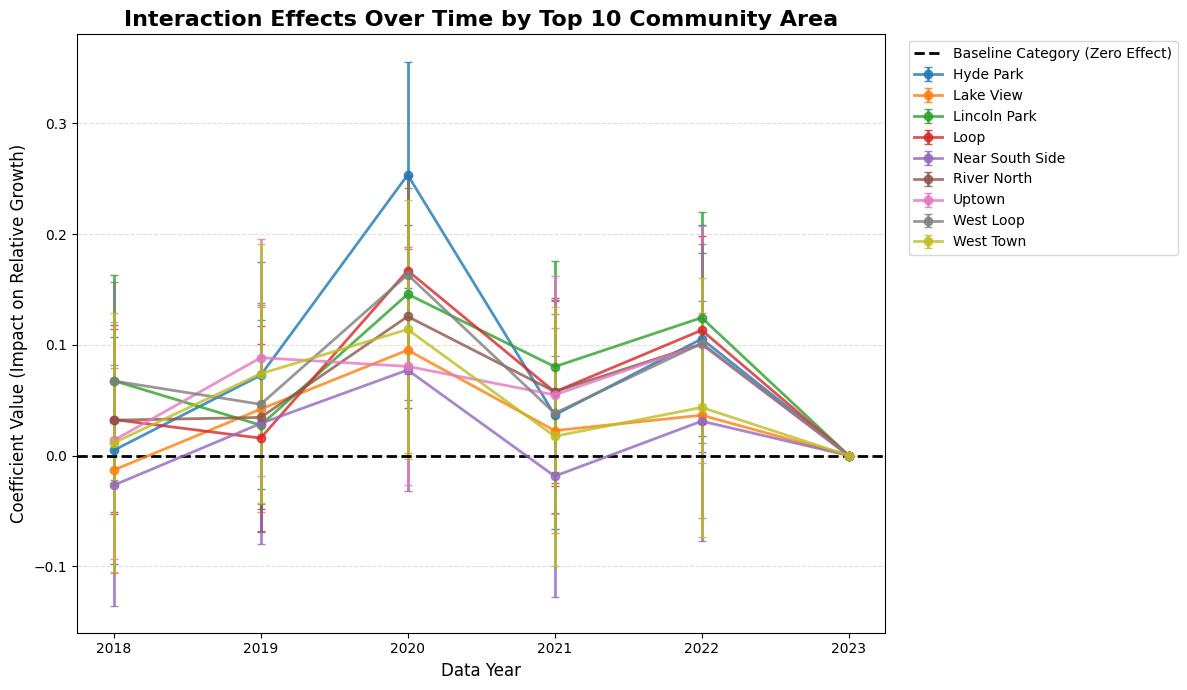

In [9]:
top_10_comm = [
    "River North",
    "Loop",
    "West Loop",
    "Lake View",
    "Lincoln Park",
    "Hyde Park",
    "Uptown",
    "Near South Side",
    "Edgewater",
    "West Town",
]

test_dataframe[test_dataframe["geo_mapped_name"].isin(top_10_comm)]

formula = "Q('target_relative_growth') ~ C(Q('Data Year')) * C(Q('geo_mapped_name'))"
model = smf.ols(
    formula, data=test_dataframe[test_dataframe["geo_mapped_name"].isin(top_10_comm)]
).fit()

fig1, ax1 = plot_categorical_interactions_over_time(
    model=model,
    time_col="Data Year",
    category_col="geo_mapped_name",
    title="Interaction Effects Over Time by Top 10 Community Area",
    xlabel="Data Year",
    ylabel="Coefficient Value (Impact on Relative Growth)",
)
plt.show()

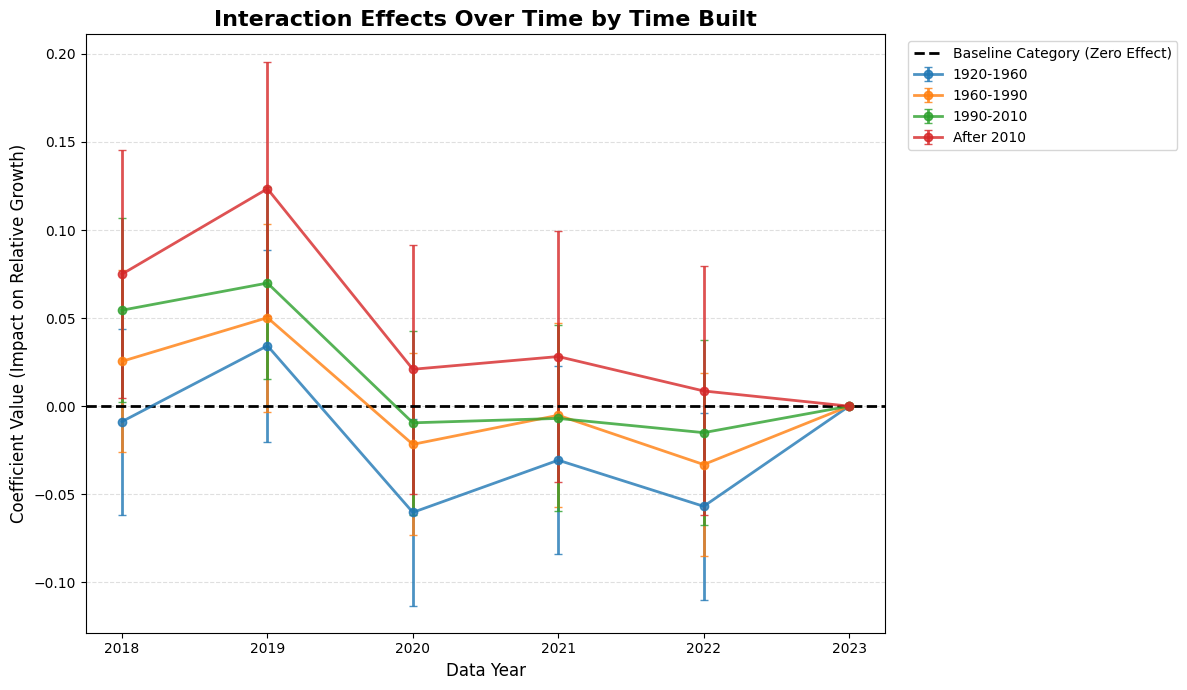

In [10]:
formula = "Q('target_relative_growth') ~ C(Q('Data Year')) * C(Q('Time Built'))"
model = smf.ols(formula, data=test_dataframe).fit()

fig1, ax1 = plot_categorical_interactions_over_time(
    model=model,
    time_col="Data Year",
    category_col="Time Built",
    title="Interaction Effects Over Time by Time Built",
    xlabel="Data Year",
    ylabel="Coefficient Value (Impact on Relative Growth)",
)
plt.show()

From looking at the trends of all the graphs it is unsurprising on how each trends. Therefore, it is no surprising variable to use as of yet. These graphs mostly tell us on the differences between each group. There is 0 for 2023 because it has no data for that yet as 2024 is not used.